# 02_prediction_matrix

This notebook simulates all selected team-vs-team matchups and builds matrix-style outputs for:

- row-team win probability
- draw probability
- column-team win probability
- most common exact score
- recommended score tip
- expected points for the recommended tip


In [1]:
# ============================================================
# 02_prediction_matrix.ipynb
# ============================================================
# Full matchup matrix using the shared simulation utilities.
# ============================================================

import os
import random
import warnings
from pathlib import Path
import itertools

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.notebook import tqdm

from utils.simulation import (
    find_optimal_tip_from_simulations,
    simulate_match_many,
)

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 200)

RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


c:\ProgramData\anaconda3\envs\geo_env\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator DummyClassifier from version 1.8.0 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\ProgramData\anaconda3\envs\geo_env\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.8.0 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\ProgramData\anaconda3\envs\geo_env\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator GradientBoostingClassifier from version 

## Configuration

Adjust `phase`, and `n_simulations_per_match` depending on the use case.

For a first run, keep the team list small and use fewer simulations. For final outputs, increase the number of simulations and include all relevant teams.


In [2]:
phase = 'group' # one of 'group', 'play-in', 'round_of_16', 'quarter_final', 'semi_final', 'final'

n_simulations_per_match = 3000 # Number of simulations to run per matchup
max_tip_goals = 6 # Cuttof for maximum goals to consider in the tip optimization
use_cached_results = True # Use pre-existing results if available, otherwise run simulations (can be time-consuming)

dir_out = Path(f'simulation_results/{phase}')
dir_out.mkdir(parents=True, exist_ok=True)
path_cache = dir_out / f'prediction_matrix_long_{phase}.csv'


In [3]:
from utils.simulation import groups

# Small selection of teams.
teams_selection = [
    'Argentina',
    'Brazil',
    'France',
    'Spain',
    'England',
    'Portugal',
    'Germany',
    'Netherlands',
    'Belgium',
    'Switzerland',
    'Croatia',
    'Uruguay',
    'Morocco',
    'Japan',
    'Senegal',
    'United States',
]

# All teams from group phase.
teams_all = sorted(set(team for group_teams in groups.values() for team in group_teams))

# Teams set to use.
teams = teams_all
# teams = teams_selection

teams = sorted(teams)

n_ordered_matrix_cells = len(teams) * (len(teams) - 1)
n_simulated_matchups = len(teams) * (len(teams) - 1) // 2

print(f'Teams: {len(teams)}')
print(f'Simulated matchups: {n_simulated_matchups:,}')
print(f'Simulations per matchup: {n_simulations_per_match:,}')
print(
    'Total simulated matches: '
    f'{n_simulated_matchups * n_simulations_per_match:,}'
)

Teams: 48
Simulated matchups: 1,128
Simulations per matchup: 3,000
Total simulated matches: 3,384,000


## Matchup summary helper

This helper runs one row-team vs column-team simulation and returns a compact, matrix-ready summary.


In [4]:
def simulate_matchup_summary(
    team_a,
    team_b,
    phase='group',
    n_simulations=3000,
    max_tip_goals=6,
    use_tqdm=False
):
    """Simulate one matchup and return matrix-ready summary values.

    Args:
        team_a: Row team.
        team_b: Column team.
        phase: Prediction-game phase
        n_simulations: Number of Monte Carlo simulations.
        max_tip_goals: Highest goals to consider for candidate score tips.

    Returns:
        Dictionary with probabilities, score summaries, and optimal tip values.
    """
    df_simulations = simulate_match_many(
        team_a=team_a,
        team_b=team_b,
        phase=phase,
        n_simulations=n_simulations,
        use_tqdm=use_tqdm
    )

    df_tiprank = find_optimal_tip_from_simulations(
        df_simulations=df_simulations,
        team_a=team_a,
        team_b=team_b,
        phase=phase,
        max_tip_goals=max_tip_goals,
    )

    best_tip = df_tiprank.iloc[0]

    outcome_probs = (
        df_simulations['result']
        .value_counts(normalize=True)
        .reindex(['A', 'D', 'B'], fill_value=0)
        .mul(100)
    )

    score_probs = df_simulations['score'].value_counts(normalize=True)
    most_common_score = score_probs.index[0]
    most_common_score_probability = score_probs.iloc[0] * 100

    avg_goals_a = df_simulations['goals_a'].mean()
    avg_goals_b = df_simulations['goals_b'].mean()

    return {
        'team_a': team_a,
        'team_b': team_b,
        'team_a_win_probability': outcome_probs['A'],
        'draw_probability': outcome_probs['D'],
        'team_b_win_probability': outcome_probs['B'],
        'most_common_score': most_common_score,
        'most_common_score_probability': most_common_score_probability,
        'recommended_tip': best_tip['tip'],
        'recommended_tip_outcome': best_tip['outcome'],
        'recommended_tip_expected_points': best_tip['expected_points'],
        'recommended_tip_exact_probability': (
            best_tip['exact_score_probability_percent']
        ),
        'avg_goals_a': avg_goals_a,
        'avg_goals_b': avg_goals_b,
        'avg_goal_difference': avg_goals_a - avg_goals_b,
    }


## Run all matchups

The matrix is row-oriented: `team_a` is the row team and `team_b` is the column opponent.

Each unordered matchup is simulated once, then mirrored into the opposite direction.
For example, `Switzerland vs Brazil` is simulated directly, and `Brazil vs Switzerland`
is derived by swapping teams, probabilities, goals, and score tips.

This avoids running the same neutral matchup twice and keeps the matrix symmetric.

In [5]:
def reverse_score(score):
    """Reverse a score string like '1-2' to '2-1'."""
    goals_a, goals_b = score.split('-')
    return f'{goals_b}-{goals_a}'


def mirror_matchup_summary(summary):
    """Mirror a team_a vs team_b summary into team_b vs team_a."""
    mirrored = summary.copy()

    mirrored.update({
        'team_a': summary['team_b'],
        'team_b': summary['team_a'],
        'team_a_win_probability': summary['team_b_win_probability'],
        'team_b_win_probability': summary['team_a_win_probability'],
        'draw_probability': summary['draw_probability'],
        'most_common_score': reverse_score(summary['most_common_score']),
        'most_common_score_probability': (
            summary['most_common_score_probability']
        ),
        'recommended_tip': reverse_score(summary['recommended_tip']),
        'recommended_tip_outcome': (
            summary['recommended_tip_outcome']
            .replace(summary['team_a'], '__TEMP__')
            .replace(summary['team_b'], summary['team_a'])
            .replace('__TEMP__', summary['team_b'])
        ),
        'recommended_tip_expected_points': (
            summary['recommended_tip_expected_points']
        ),
        'recommended_tip_exact_probability': (
            summary['recommended_tip_exact_probability']
        ),
        'avg_goals_a': summary['avg_goals_b'],
        'avg_goals_b': summary['avg_goals_a'],
        'avg_goal_difference': -summary['avg_goal_difference'],
    })

    return mirrored

In [7]:
if use_cached_results and path_cache.exists():
    df_matrix_long = pd.read_csv(path_cache)
    print(f'Loaded cached results from: {path_cache}')
else:
    if path_cache.exists():
        print(f'Cache file already exists at {path_cache}. Removing it to run fresh simulations.')
        path_cache.unlink()
    rows = []
    matchups = list(itertools.combinations(teams, 2))
    for team_a, team_b in tqdm(matchups, desc='Simulating matchups', unit='matchup'):
        summary = simulate_matchup_summary(
            team_a=team_a,
            team_b=team_b,
            phase=phase,
            n_simulations=n_simulations_per_match,
            max_tip_goals=max_tip_goals,
        )

        rows.append(summary)
        rows.append(mirror_matchup_summary(summary))

    df_matrix_long = pd.DataFrame(rows)
    df_matrix_long.to_csv(path_cache, index=False)

    print(f'Saved long-format results to: {path_cache}')

df_matrix_long.head()

Loaded cached results from: simulation_results\group\prediction_matrix_long_group.csv


,team_a,team_b,team_a_win_probability,draw_probability,team_b_win_probability,most_common_score,most_common_score_probability,recommended_tip,recommended_tip_outcome,recommended_tip_expected_points,recommended_tip_exact_probability,avg_goals_a,avg_goals_b,avg_goal_difference
0,Algeria,Argentina,10.600000,37.833333,51.566667,1-1,17.433333,0-1,Argentina win,4.178333,14.733333,0.668333,1.456333,-0.788000
1,Argentina,Algeria,51.566667,37.833333,10.600000,1-1,17.433333,1-0,Algeria win,4.178333,14.733333,1.456333,0.668333,0.788000
2,Algeria,Australia,21.866667,50.166667,27.966667,0-0,21.733333,1-1,Draw,4.770000,21.300000,0.891000,1.018667,-0.127667
3,Australia,Algeria,27.966667,50.166667,21.866667,0-0,21.733333,1-1,Draw,4.770000,21.300000,1.018667,0.891000,0.127667
4,Algeria,Austria,28.533333,47.066667,24.400000,1-1,21.700000,1-1,Draw,4.554333,21.700000,1.012333,0.943000,0.069333


## Create matrix tables

In [8]:
def make_matrix(value_column):
    """Return a team-vs-team matrix for a selected value column."""
    return (
        df_matrix_long
        .pivot(index='team_a', columns='team_b', values=value_column)
        .reindex(index=teams, columns=teams)
    )


df_row_win_matrix = make_matrix('team_a_win_probability')
df_draw_matrix = make_matrix('draw_probability')
df_col_win_matrix = make_matrix('team_b_win_probability')
df_tip_matrix = make_matrix('recommended_tip')
df_tip_points_matrix = make_matrix('recommended_tip_expected_points')
df_score_matrix = make_matrix('most_common_score')
df_score_probability_matrix = make_matrix('most_common_score_probability')
df_avg_goal_diff_matrix = make_matrix('avg_goal_difference')

df_row_win_matrix.head()


team_b,Algeria,Argentina,Australia,Austria,Belgium,Bosnia and Herzegovina,Brazil,Canada,Cape Verde,Colombia,Croatia,Curaçao,Czech Republic,DR Congo,Ecuador,Egypt,England,France,Germany,Ghana,Haiti,Iran,Iraq,Ivory Coast,Japan,Jordan,Mexico,Morocco,Netherlands,New Zealand,Norway,Panama,Paraguay,Portugal,Qatar,Saudi Arabia,Scotland,Senegal,South Africa,South Korea,Spain,Sweden,Switzerland,Tunisia,Turkey,United States,Uruguay,Uzbekistan
team_a,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Algeria,NaN,10.600000,21.866667,28.533333,17.766667,53.266667,18.666667,27.533333,43.166667,25.133333,16.900000,48.866667,43.600000,35.033333,29.700000,28.500000,16.600000,10.700000,18.100000,39.666667,51.600000,20.966667,42.600000,26.466667,17.066667,48.500000,17.866667,12.400000,17.100000,37.800000,27.700000,26.433333,40.500000,14.600000,46.500000,43.700000,36.933333,24.466667,45.000000,19.633333,12.633333,44.433333,25.100000,40.966667,26.666667,20.033333,25.633333,42.833333
Argentina,51.566667,NaN,60.000000,66.333333,58.800000,69.866667,28.300000,57.300000,56.966667,28.133333,45.966667,71.366667,71.066667,70.900000,53.566667,66.300000,39.933333,30.033333,44.266667,60.000000,61.566667,56.533333,71.966667,65.933333,56.533333,66.766667,53.733333,45.633333,50.466667,52.933333,68.600000,61.966667,42.400000,47.233333,67.300000,73.133333,73.266667,54.400000,73.200000,60.233333,31.533333,78.566667,62.466667,70.400000,66.533333,58.933333,54.500000,67.266667
Australia,27.966667,8.066667,NaN,28.800000,21.233333,59.233333,21.000000,28.466667,51.866667,26.666667,17.333333,54.400000,45.633333,42.200000,32.633333,27.033333,19.433333,10.566667,20.500000,42.066667,54.166667,22.466667,44.600000,30.233333,15.733333,50.833333,18.566667,12.766667,17.766667,34.500000,30.266667,28.566667,44.766667,15.966667,48.933333,41.966667,42.433333,19.033333,50.700000,26.900000,13.400000,46.366667,27.433333,41.533333,29.666667,19.900000,26.066667,39.033333
Austria,24.400000,5.866667,26.533333,NaN,16.600000,43.400000,16.766667,26.400000,43.633333,23.200000,13.400000,46.600000,40.866667,36.966667,30.433333,24.033333,13.766667,8.933333,17.666667,35.533333,48.233333,19.766667,40.500000,27.000000,14.433333,51.133333,15.233333,10.166667,14.933333,35.333333,24.366667,26.466667,41.800000,10.900000,41.700000,41.733333,33.033333,14.966667,47.800000,18.566667,10.600000,40.933333,19.766667,38.866667,27.400000,16.700000,20.833333,38.033333
Belgium,36.766667,8.900000,38.733333,41.566667,NaN,57.900000,27.466667,45.333333,58.800000,35.400000,29.933333,67.500000,51.733333,55.466667,52.200000,48.433333,18.600000,14.233333,25.500000,51.533333,66.200000,44.400000,58.400000,51.366667,31.533333,63.166667,35.033333,18.833333,26.800000,50.700000,49.800000,49.600000,61.633333,19.100000,61.533333,59.266667,57.133333,28.166667,60.833333,42.366667,15.666667,62.700000,41.600000,55.966667,54.166667,31.433333,40.200000,52.733333


## Save matrix outputs

In [9]:
matrix_outputs = {
    f'row_team_win_probability_matrix_{phase}.csv': df_row_win_matrix,
    f'draw_probability_matrix_{phase}.csv': df_draw_matrix,
    f'column_team_win_probability_matrix_{phase}.csv': df_col_win_matrix,
    f'recommended_tip_matrix_{phase}.csv': df_tip_matrix,
    f'recommended_tip_expected_points_matrix_{phase}.csv': df_tip_points_matrix,
    f'most_common_score_matrix_{phase}.csv': df_score_matrix,
    f'most_common_score_probability_matrix_{phase}.csv': (
        df_score_probability_matrix
    ),
    f'avg_goal_difference_matrix_{phase}.csv': df_avg_goal_diff_matrix,
}

for filename, df_output in matrix_outputs.items():
    path_out = dir_out / filename
    df_output.to_csv(path_out)
    print(f'Saved: {path_out}')


Saved: simulation_results\group\row_team_win_probability_matrix_group.csv
Saved: simulation_results\group\draw_probability_matrix_group.csv
Saved: simulation_results\group\column_team_win_probability_matrix_group.csv
Saved: simulation_results\group\recommended_tip_matrix_group.csv
Saved: simulation_results\group\recommended_tip_expected_points_matrix_group.csv
Saved: simulation_results\group\most_common_score_matrix_group.csv
Saved: simulation_results\group\most_common_score_probability_matrix_group.csv
Saved: simulation_results\group\avg_goal_difference_matrix_group.csv


## Plot: win probability matrix

Cell values show the probability that the row team beats the column team.


In [10]:
n_teams = len(df_tip_matrix)
cell_size = 0.25
margin = 4
fig_size = n_teams * cell_size + margin

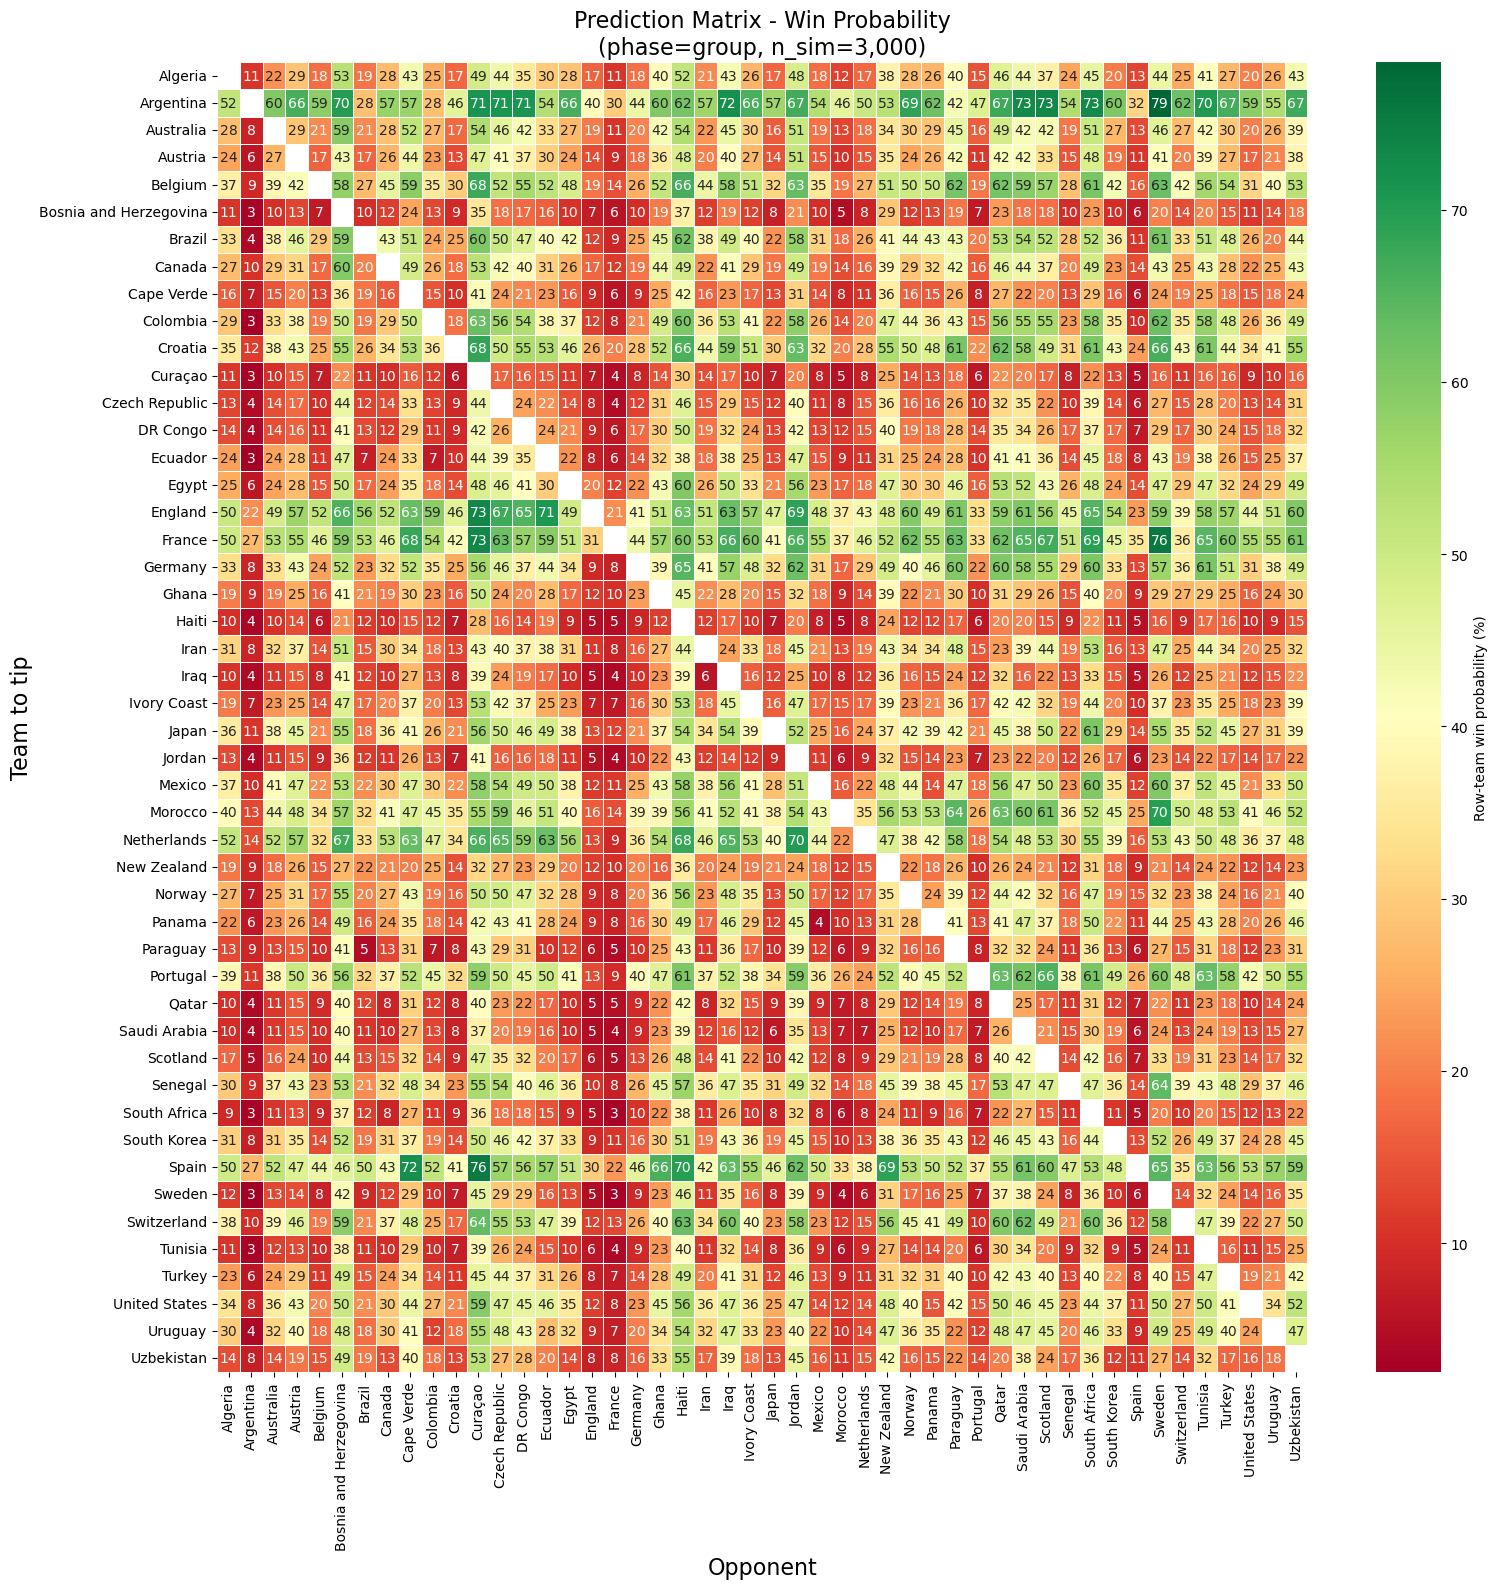

In [11]:
plt.figure(figsize=(fig_size, fig_size))

sns.heatmap(
    df_row_win_matrix,
    annot=True,
    fmt='.0f',
    cmap='RdYlGn',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Row-team win probability (%)'},
)

plt.title(
    f'Prediction Matrix - Win Probability'
    f'\n(phase={phase}, n_sim={n_simulations_per_match:,})',
    fontsize=16,
    # fontweight='bold',
)
plt.xlabel('Opponent', fontsize=16)
plt.ylabel('Team to tip', fontsize=16)
plt.tight_layout()
plt.show()


## Plot: recommended tip matrix

Cell text shows the recommended score tip. Colour shows the expected points of that tip.


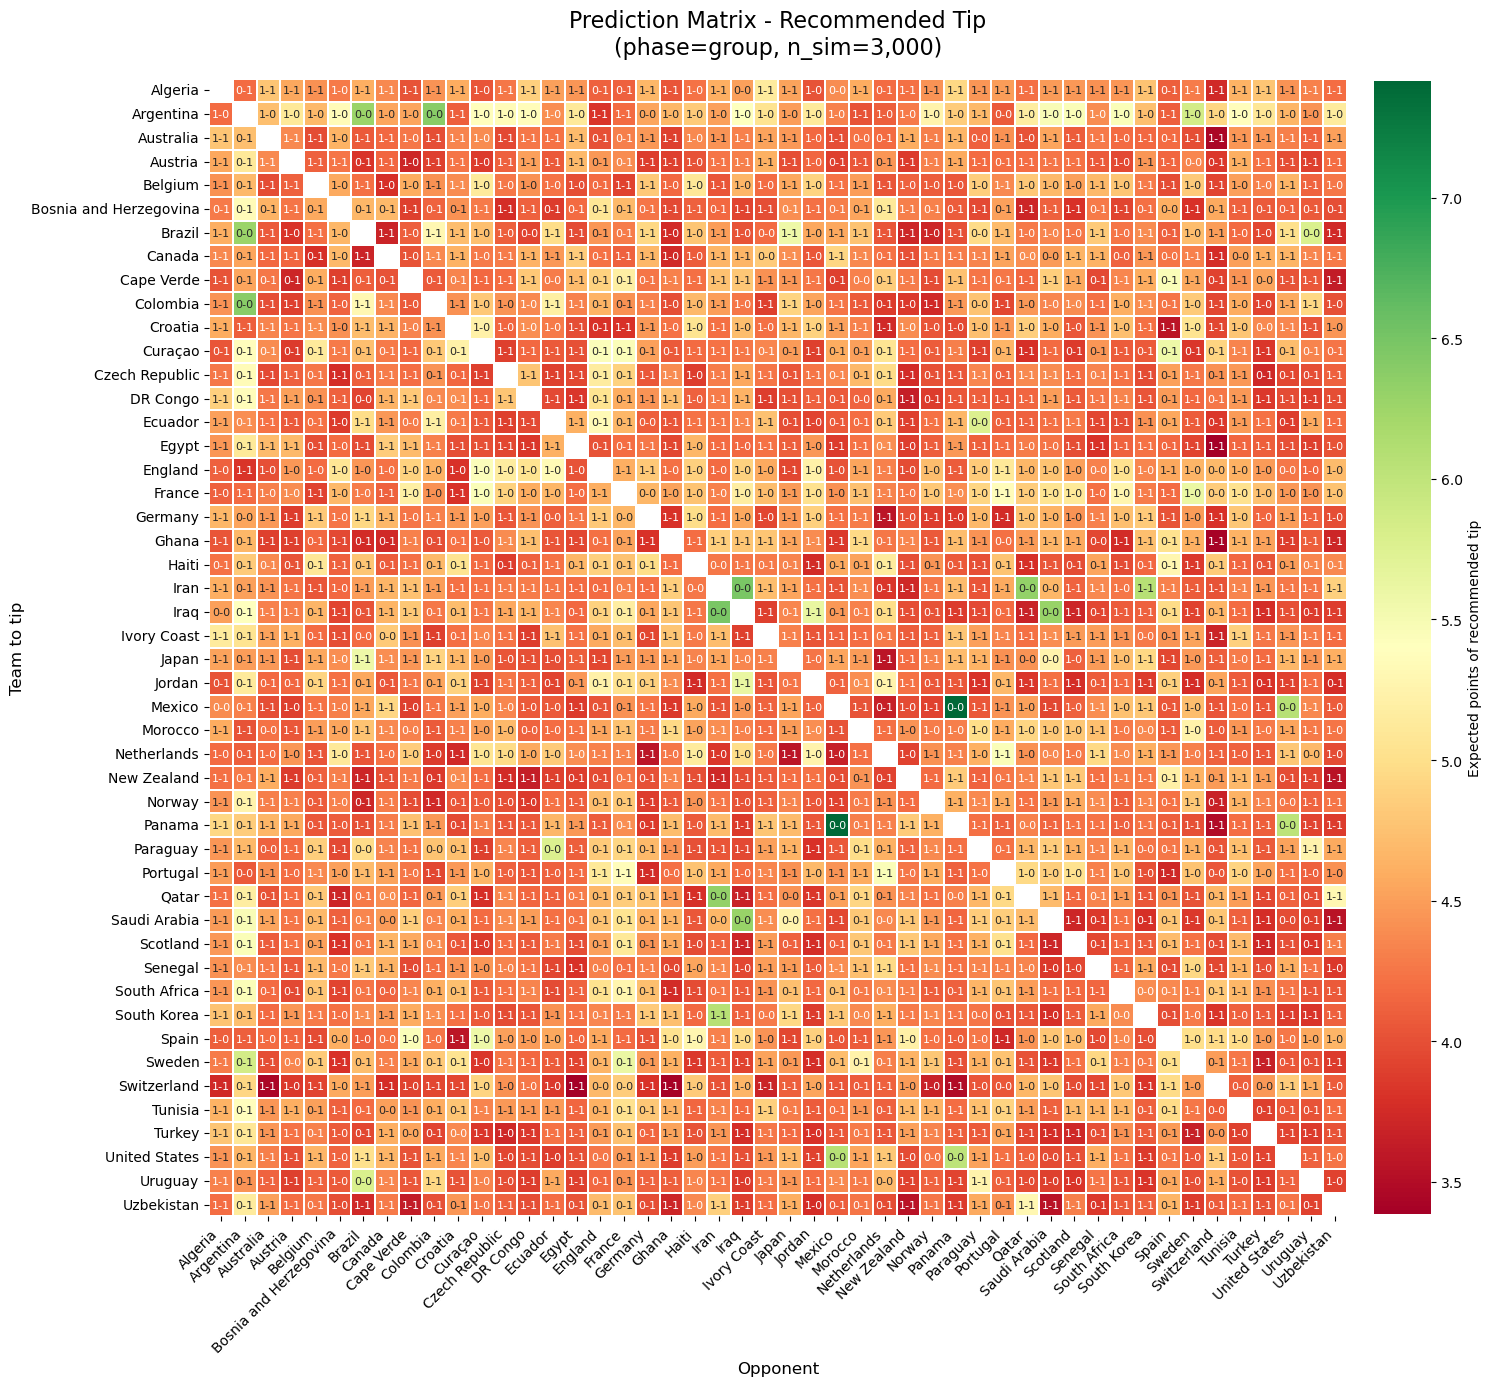

In [12]:
fig, ax = plt.subplots(figsize=(fig_size, fig_size))

sns.heatmap(
    df_tip_points_matrix,
    annot=df_tip_matrix,
    fmt='',
    cmap='RdYlGn',
    linewidths=0.25,
    linecolor='white',
    square=True,
    ax=ax,
    cbar_kws={
        'label': 'Expected points of recommended tip',
        'shrink': 0.75,
        'pad': 0.02,
    },
    annot_kws={
        'fontsize': 8,
        'ha': 'center',
        'va': 'center',
    },
)

ax.set_title(
    f'Prediction Matrix - Recommended Tip'
    f'\n(phase={phase}, n_sim={n_simulations_per_match:,})',
    fontsize=16,
    # fontweight='bold',
    pad=18,
)

ax.set_xlabel('Opponent', fontsize=12)
ax.set_ylabel('Team to tip', fontsize=12)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha='right',
    fontsize=10,
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=10,
)

plt.tight_layout()
plt.show()

## Plot: most common exact score matrix

Cell text shows the most common exact score. Colour shows how often that exact score appears in the simulations.


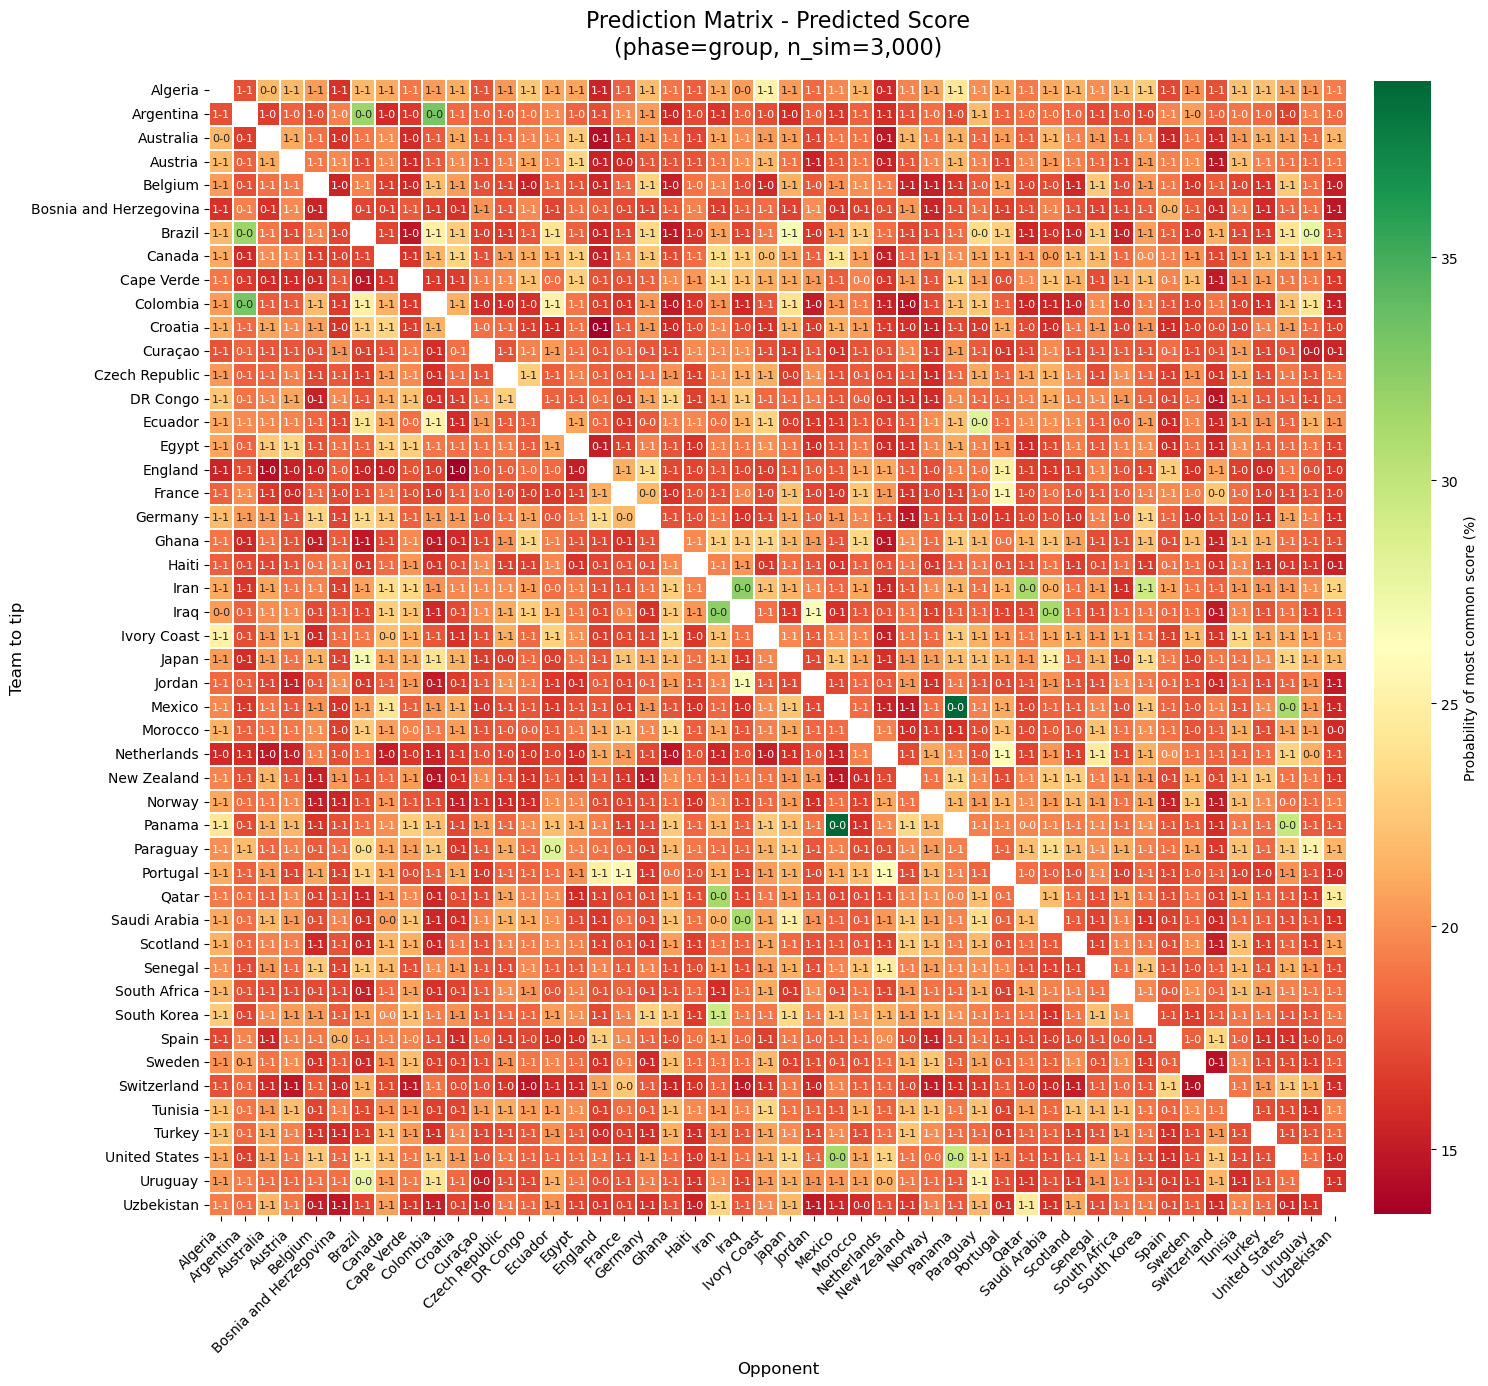

In [13]:
fig, ax = plt.subplots(figsize=(fig_size, fig_size))

sns.heatmap(
    df_score_probability_matrix,
    annot=df_score_matrix,
    fmt='',
    cmap='RdYlGn',
    linewidths=0.25,
    linecolor='white',
    square=True,
    ax=ax,
    cbar_kws={
        'label': 'Probability of most common score (%)',
        'shrink': 0.75,
        'pad': 0.02,
    },
    annot_kws={
        'fontsize': 8,
        'ha': 'center',
        'va': 'center',
    },
)

ax.set_title(
    f'Prediction Matrix - Predicted Score'
    f'\n(phase={phase}, n_sim={n_simulations_per_match:,})',
    fontsize=16,
    # fontweight='bold',
    pad=18,
)

ax.set_xlabel('Opponent', fontsize=12)
ax.set_ylabel('Team to tip', fontsize=12)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha='right',
    fontsize=10,
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=10,
)

plt.tight_layout()
plt.show()

## Plot: average goal-difference matrix

Positive values favour the row team. Negative values favour the column team.


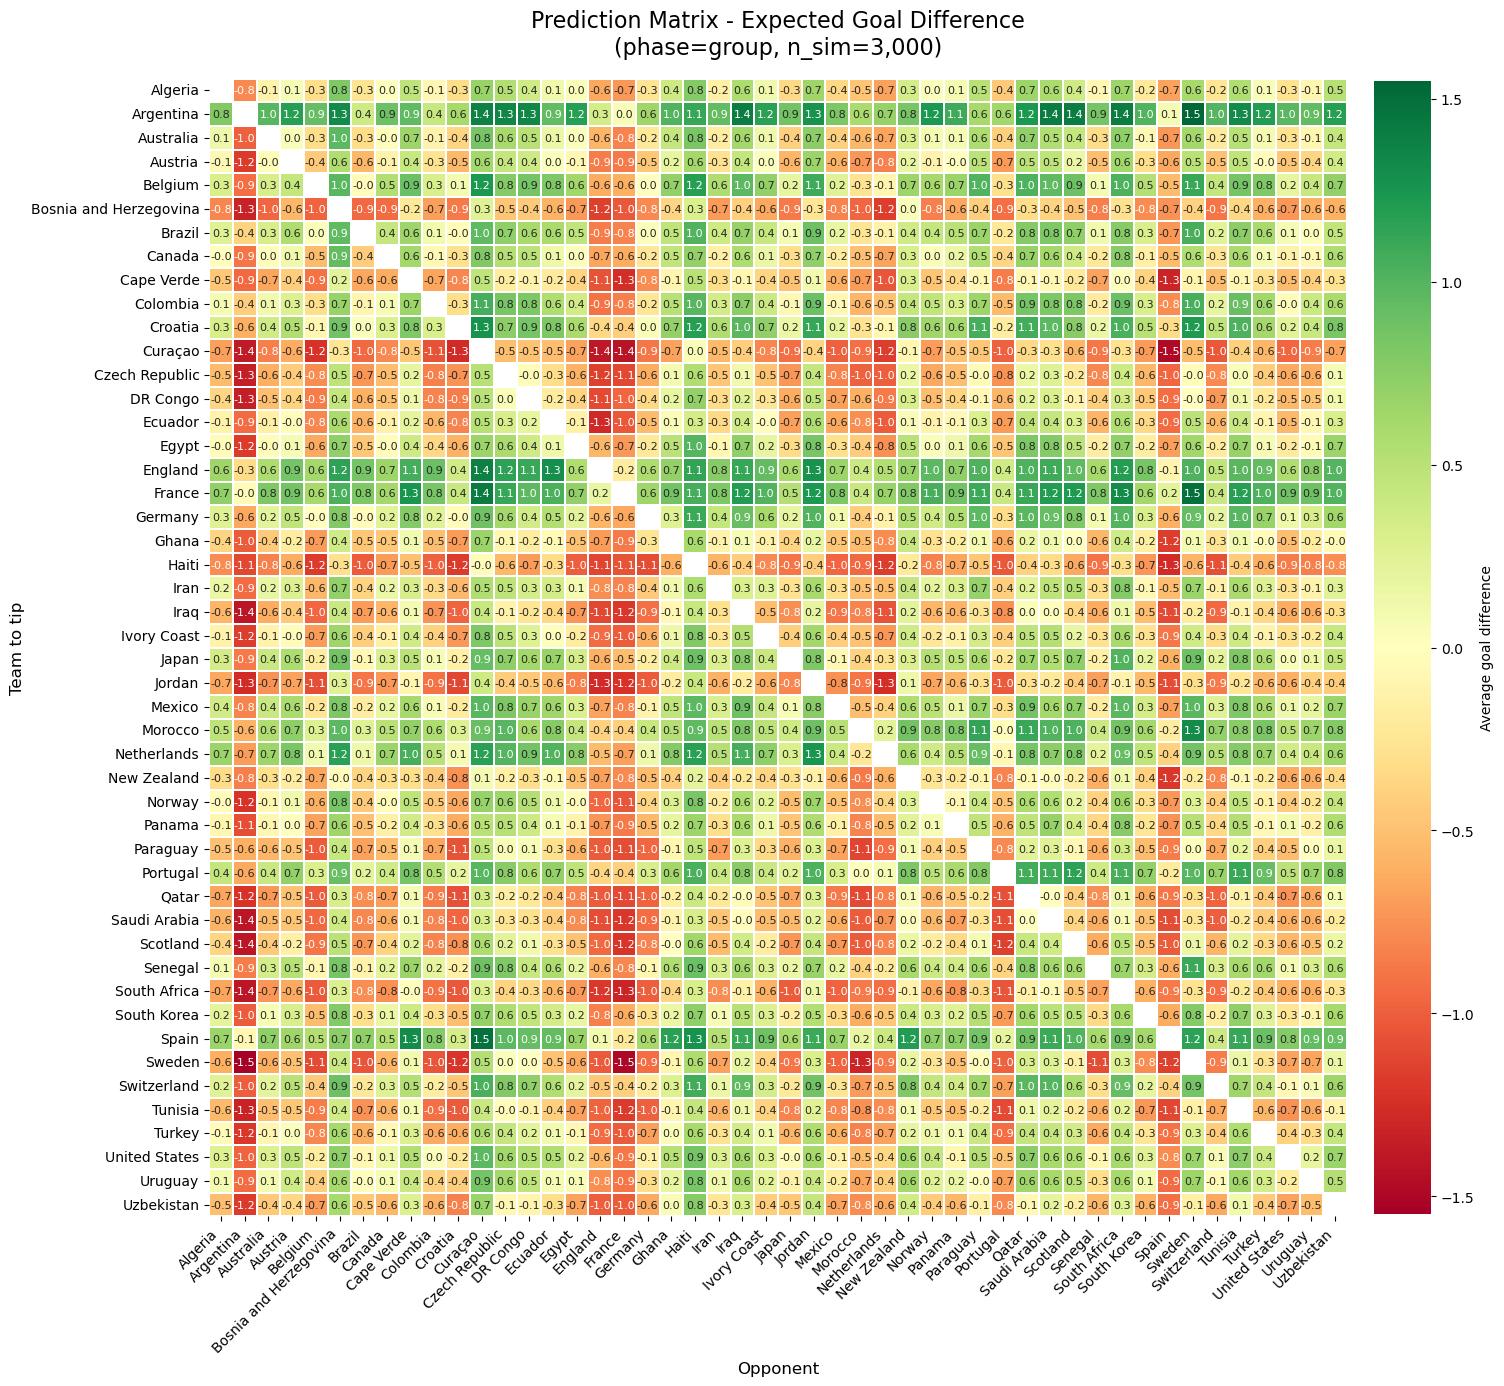

In [14]:
goal_diff_abs_max = np.nanmax(np.abs(df_avg_goal_diff_matrix.values))

fig, ax = plt.subplots(figsize=(fig_size, fig_size))

sns.heatmap(
    df_avg_goal_diff_matrix,
    annot=True,
    fmt='.1f',
    vmin=-goal_diff_abs_max,
    vmax=goal_diff_abs_max,
    cmap='RdYlGn',
    linewidths=0.25,
    linecolor='white',
    square=True,
    ax=ax,
    cbar_kws={
        'label': 'Average goal difference',
        'shrink': 0.75,
        'pad': 0.02,
    },
    annot_kws={
        'fontsize': 8,
        'ha': 'center',
        'va': 'center',
    },
)

ax.set_title(
    f'Prediction Matrix - Expected Goal Difference'
    f'\n(phase={phase}, n_sim={n_simulations_per_match:,})',
    fontsize=16,
    # fontweight='bold',
    pad=18,
)

ax.set_xlabel('Opponent', fontsize=12)
ax.set_ylabel('Team to tip', fontsize=12)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha='right',
    fontsize=10,
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=10,
)

plt.tight_layout()
plt.show()

## Team ranking summary

This summarizes each row team's average performance across all selected opponents.


In [15]:
df_team_strength = (
    df_matrix_long
    .groupby('team_a')
    .agg(
        avg_win_probability=('team_a_win_probability', 'mean'),
        avg_draw_probability=('draw_probability', 'mean'),
        avg_loss_probability=('team_b_win_probability', 'mean'),
        avg_recommended_tip_expected_points=(
            'recommended_tip_expected_points',
            'mean',
        ),
        avg_goals_for=('avg_goals_a', 'mean'),
        avg_goals_against=('avg_goals_b', 'mean'),
        avg_goal_difference=('avg_goal_difference', 'mean'),
    )
    .sort_values('avg_win_probability', ascending=False)
)

df_team_strength


,avg_win_probability,avg_draw_probability,avg_loss_probability,avg_recommended_tip_expected_points,avg_goals_for,avg_goals_against,avg_goal_difference
team_a,,,,,,,
Argentina,57.971631,33.965957,8.062411,4.847582,1.583028,0.614319,0.968709
France,54.056738,36.788652,9.154610,4.628326,1.502326,0.646355,0.855972
England,52.499291,35.543972,11.956738,4.536461,1.475489,0.698794,0.776695
Spain,51.429787,36.613475,11.956738,4.444766,1.451879,0.699291,0.752589
Netherlands,45.646809,36.395035,17.958156,4.387000,1.348028,0.813766,0.534262
Morocco,44.910638,41.356028,13.733333,4.430255,1.327851,0.746177,0.581674
Portugal,44.248227,40.791489,14.960284,4.441752,1.316362,0.765936,0.550426
Croatia,43.832624,38.514184,17.653191,4.377121,1.314163,0.814078,0.500085
Belgium,43.751773,37.362411,18.885816,4.386667,1.311135,0.834567,0.476567


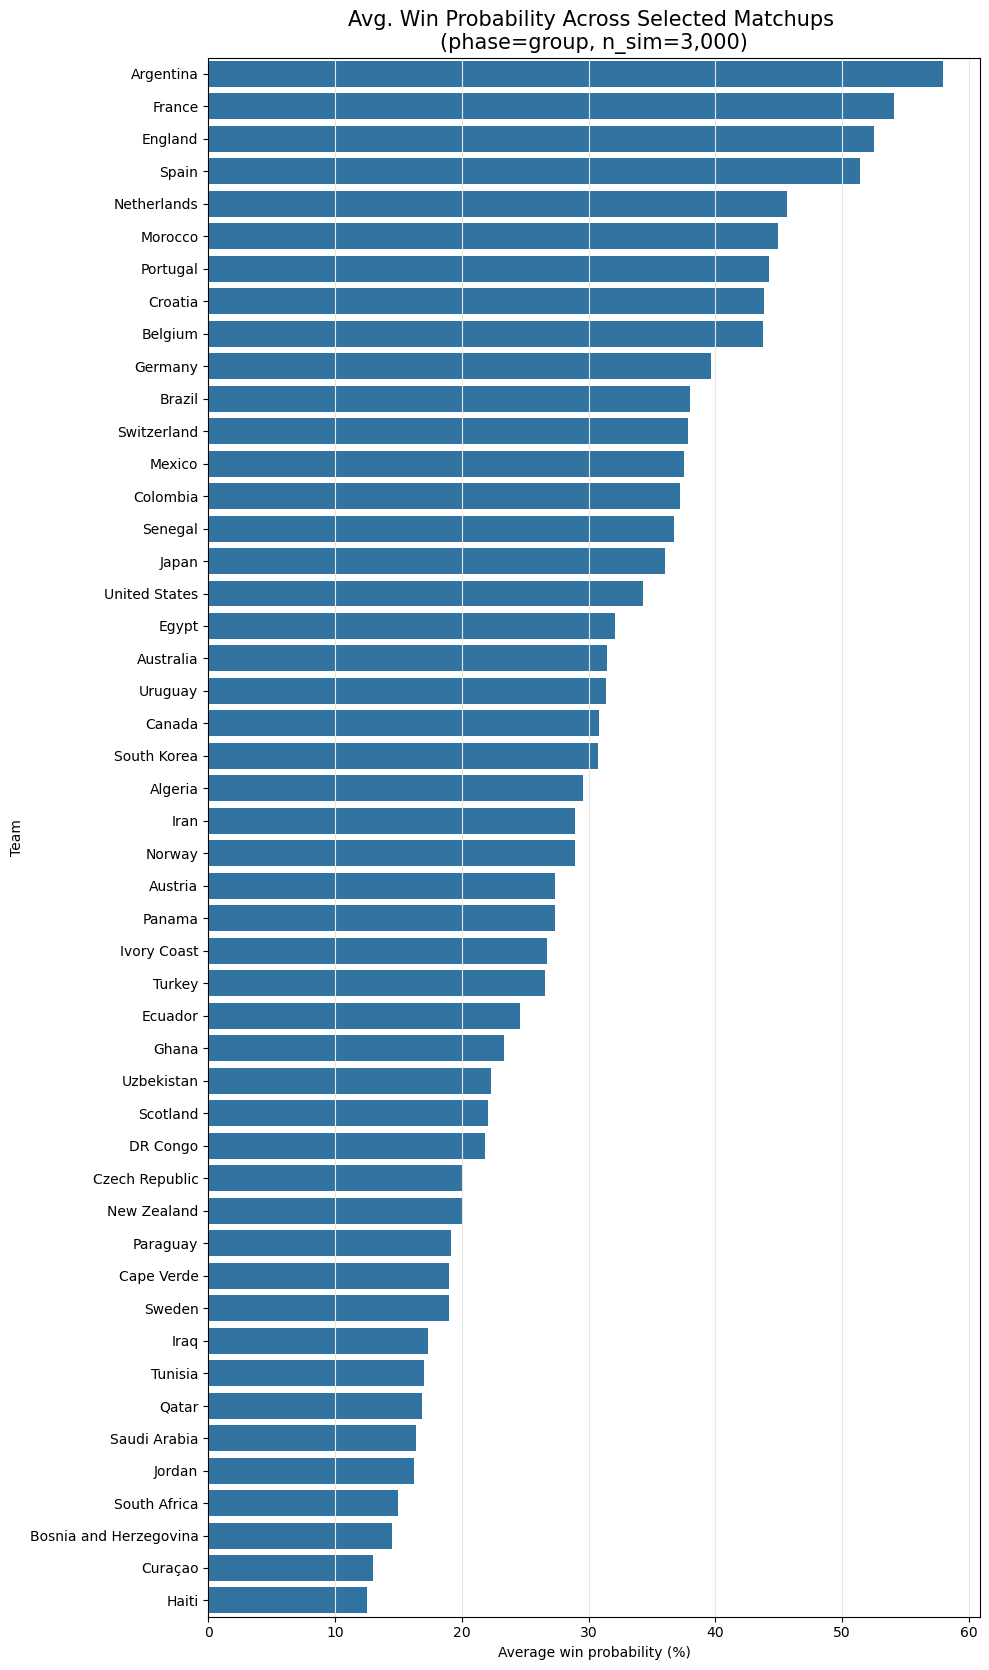

In [16]:
df_team_strength_plot = df_team_strength.reset_index()

plt.figure(figsize=(10, max(6, len(df_team_strength_plot) * 0.35)))

sns.barplot(
    data=df_team_strength_plot,
    x='avg_win_probability',
    y='team_a',
    color='#1f77b4',
)

plt.title(
    f'Avg. Win Probability Across Selected Matchups '
    f'\n(phase={phase}, n_sim={n_simulations_per_match:,})',
    fontsize=15,
    # fontweight='bold',
)
plt.xlabel('Average win probability (%)')
plt.ylabel('Team')
plt.grid(axis='x', color='#e6e6e6')
plt.tight_layout()
plt.show()


## Inspect one matchup

In [17]:
inspect_team_a = 'Switzerland'
inspect_team_b = 'Brazil'

df_matrix_long[
    (df_matrix_long['team_a'] == inspect_team_a)
    & (df_matrix_long['team_b'] == inspect_team_b)
]


,team_a,team_b,team_a_win_probability,draw_probability,team_b_win_probability,most_common_score,most_common_score_probability,recommended_tip,recommended_tip_outcome,recommended_tip_expected_points,recommended_tip_exact_probability,avg_goals_a,avg_goals_b,avg_goal_difference
605,Switzerland,Brazil,20.666667,46.466667,32.866667,1-1,21.3,1-1,Draw,4.495,21.3,0.887333,1.119667,-0.232333


## Final summary

In [18]:
print('Prediction matrix complete.')
print(f'Teams: {len(teams)}')
print(f'Ordered matchups: {len(df_matrix_long):,}')
print(f'Simulations per matchup: {n_simulations_per_match:,}')
print(f'Total simulated matches: {len(df_matrix_long) * n_simulations_per_match:,}')
print()
print('Top teams by average win probability:')
display(df_team_strength.head(10))


Prediction matrix complete.
Teams: 48
Ordered matchups: 2,256
Simulations per matchup: 3,000
Total simulated matches: 6,768,000

Top teams by average win probability:


,avg_win_probability,avg_draw_probability,avg_loss_probability,avg_recommended_tip_expected_points,avg_goals_for,avg_goals_against,avg_goal_difference
team_a,,,,,,,
Argentina,57.971631,33.965957,8.062411,4.847582,1.583028,0.614319,0.968709
France,54.056738,36.788652,9.154610,4.628326,1.502326,0.646355,0.855972
England,52.499291,35.543972,11.956738,4.536461,1.475489,0.698794,0.776695
Spain,51.429787,36.613475,11.956738,4.444766,1.451879,0.699291,0.752589
Netherlands,45.646809,36.395035,17.958156,4.387000,1.348028,0.813766,0.534262
Morocco,44.910638,41.356028,13.733333,4.430255,1.327851,0.746177,0.581674
Portugal,44.248227,40.791489,14.960284,4.441752,1.316362,0.765936,0.550426
Croatia,43.832624,38.514184,17.653191,4.377121,1.314163,0.814078,0.500085
Belgium,43.751773,37.362411,18.885816,4.386667,1.311135,0.834567,0.476567
